In [0]:
booking=spark.read.csv("/Volumes/airline_operations/airline/filestorage/booking.csv").toDF("booking_id","flight_id","passenger_name","travel_class","ticket_price","booking_date")
flight=spark.read.csv("/Volumes/airline_operations/airline/filestorage/Flights.csv").toDF("flight_id","airline","from_city","to_city","duration","status")
passenger_preference=spark.read.option("multiline","true").json("/Volumes/airline_operations/airline/filestorage/passenger_preferences.json")

In [0]:
booking.show()
booking.printSchema()

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1008|     F107|    Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1009|     F108|     Kiran Rao|        Economy|        9500|  2026-06-05|
|     B1010|     F109|   Nisha Reddy|   

In [0]:
flight.show()

+---------+---------+---------+---------+--------+---------+
|flight_id|  airline|from_city|  to_city|duration|   status|
+---------+---------+---------+---------+--------+---------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|
|     F112|  Vistara|      Goa|    Delhi|     150|Cancelled|
|     F113|    Akasa|  Chennai|     Pune|     100|  On Time|
|     F114|Air India|  K

In [0]:
passenger_preference.show()

+-------------+-------+--------------+------+
|extra_baggage|   meal|passenger_name|  seat|
+-------------+-------+--------------+------+
|         true|    Veg|  Rahul Sharma|Window|
|        false|Non-Veg|   Priya Reddy| Aisle|
|        false|    Veg|    Amit Kumar|Middle|
|         true|   Jain|   Sneha Patel|Window|
|        false|Non-Veg|    Farhan Ali| Aisle|
|         true|    Veg|    Neha Singh|Window|
|        false|    Veg|   Arjun Verma|Middle|
|         true|   Jain|    Meera Nair|Window|
|        false|    Veg|     Kiran Rao| Aisle|
|         true|Non-Veg|   Nisha Reddy|Window|
|        false|    Veg|  David Thomas|Middle|
|         true|   Jain|   Ayesha Khan|Window|
|        false|    Veg|  Rohit Sharma| Aisle|
|         true|Non-Veg|   Pooja Mehta|Window|
|        false|    Veg|  Sanjay Gupta|Middle|
|         true|   Jain|    Divya Iyer|Window|
+-------------+-------+--------------+------+



In [0]:
from pyspark.sql.functions import col
passenger_preference=passenger_preference.select(col("passenger_name"),col("seat"),col("meal"),col("extra_baggage"))

+---------+-------+
|  airline|revenue|
+---------+-------+
|Air India|68000.0|
|    Akasa|62000.0|
|   Indigo|90000.0|
|  Vistara|71500.0|
+---------+-------+



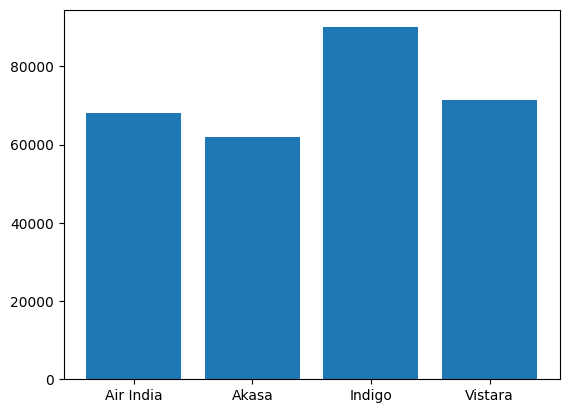

In [0]:
import matplotlib.pyplot as plt
revenue_by_airline=booking.join(flight,booking.flight_id==flight.flight_id).groupBy("airline").agg({"ticket_price":"sum"}).withColumnRenamed("sum(ticket_price)","revenue")
revenue_by_airline.show()
plt.bar(revenue_by_airline.toPandas()["airline"],revenue_by_airline.toPandas()["revenue"])
plt.show()

+---------------+--------+
|   travel_class| revenue|
+---------------+--------+
|       Business|122000.0|
|Premium Economy| 81500.0|
|        Economy| 88000.0|
+---------------+--------+



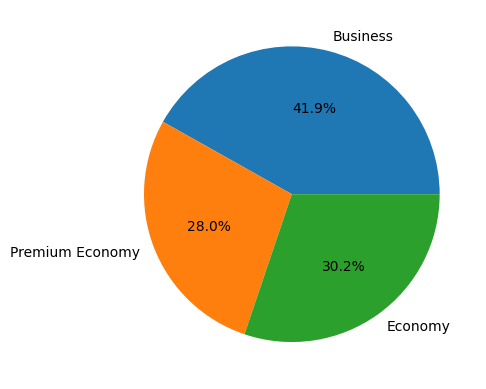

In [0]:
revenue_by_travel_class=booking.groupBy("travel_class").agg({"ticket_price":"sum"}).withColumnRenamed("sum(ticket_price)","revenue")
revenue_by_travel_class.show()
plt.pie(revenue_by_travel_class.toPandas()["revenue"],labels=revenue_by_travel_class.toPandas()["travel_class"],autopct="%1.1f%%")
plt.show()

+---------+-----+
|   status|count|
+---------+-----+
|  On Time|    9|
|  Delayed|    4|
|Cancelled|    2|
+---------+-----+



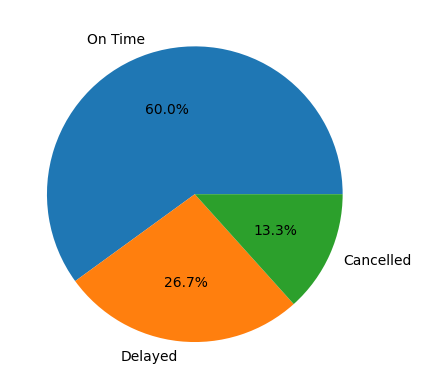

In [0]:
flight_by_status=flight.groupBy("status").count()
flight_by_status.show()
plt.pie(flight_by_status.toPandas()["count"],labels=flight_by_status.toPandas()["status"],autopct="%1.1f%%")
plt.show()


+---------+---------+-------+
|from_city|  to_city|revenue|
+---------+---------+-------+
|Hyderabad|    Delhi|39000.0|
|Bangalore|Hyderabad|38000.0|
|    Delhi|  Chennai|28000.0|
|Hyderabad|  Kolkata|26500.0|
|  Chennai|Bangalore|25000.0|
|  Chennai|     Pune|24000.0|
|Bangalore|   Mumbai|23500.0|
|    Delhi|Hyderabad|18000.0|
|Hyderabad|      Goa|16000.0|
|  Kolkata|Bangalore|10500.0|
|     Pune|    Delhi|10000.0|
|   Mumbai|Hyderabad| 9500.0|
|   Mumbai|  Chennai| 9000.0|
|    Delhi|   Mumbai| 7500.0|
|      Goa|    Delhi| 7000.0|
+---------+---------+-------+



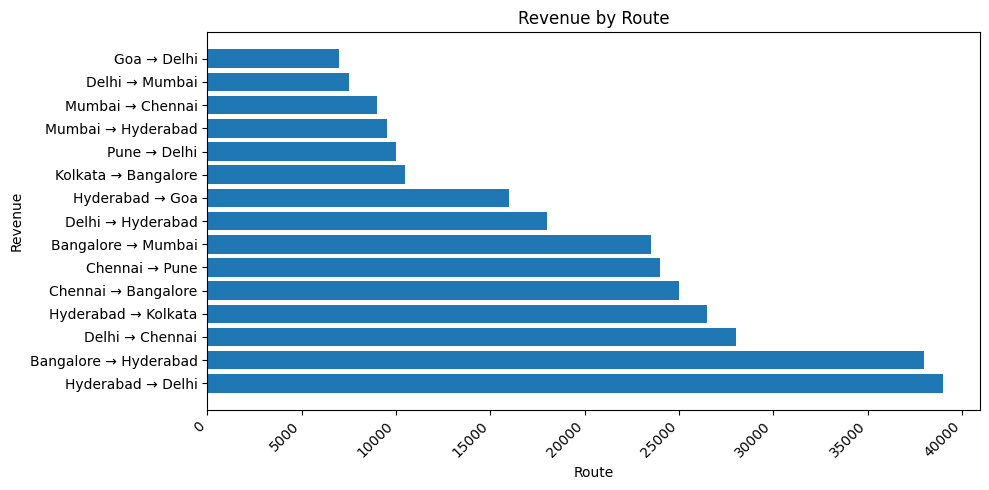

In [0]:
revenue_by_route = (
    booking.join(flight, booking.flight_id == flight.flight_id)
    .groupBy(flight["from_city"], flight["to_city"])
    .agg({"ticket_price": "sum"})
    .withColumnRenamed("sum(ticket_price)", "revenue")
    .orderBy("revenue", ascending=False)
)
revenue_by_route.show()

route_pd = revenue_by_route.toPandas()
route_pd["route"] = route_pd["from_city"] + " → " + route_pd["to_city"]

plt.figure(figsize=(10, 5))
plt.barh(route_pd["route"], route_pd["revenue"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Route")
plt.ylabel("Revenue")
plt.title("Revenue by Route")
plt.tight_layout()
plt.show()

In [0]:
revenue_by_route = (
    booking.join(flight, booking.flight_id == flight.flight_id)
    .groupBy("from_city", "to_city")
    .agg({"ticket_price": "sum"})
    .withColumnRenamed("sum(ticket_price)", "revenue")
    .orderBy("revenue", ascending=False)
)
revenue_by_route.show()

route_pd = revenue_by_route.toPandas()
route_pd["route"] = route_pd["from_city"] + " → " + route_pd["to_city"]

plt.figure(figsize=(10, 5))
plt.bar(route_pd["route"], route_pd["revenue"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Route")
plt.ylabel("Revenue")
plt.title("Revenue by Route")
plt.tight_layout()
plt.show()

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date,flight_id,airline,from_city,to_city,duration,status
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,F101,Indigo,Hyderabad,Delhi,140,On Time
B1002,F101,Priya Reddy,Business,22000,2026-06-01,F101,Indigo,Hyderabad,Delhi,140,On Time
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,F102,Air India,Mumbai,Chennai,120,Delayed
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,F103,Vistara,Bangalore,Hyderabad,90,On Time
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,F104,Indigo,Delhi,Mumbai,130,Cancelled
B1006,F105,Neha Singh,Business,25000,2026-06-03,F105,Air India,Chennai,Bangalore,80,On Time
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,F106,Akasa,Pune,Delhi,150,Delayed
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,F107,Vistara,Hyderabad,Kolkata,160,On Time
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,F108,Indigo,Mumbai,Hyderabad,110,On Time
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,F109,Akasa,Delhi,Chennai,145,Delayed


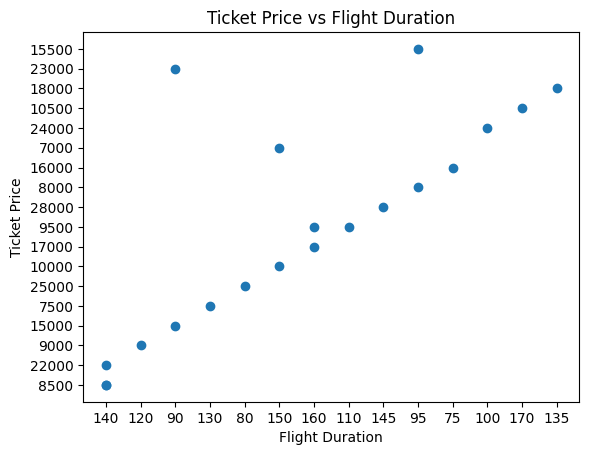

In [0]:
from pyspark.sql.functions import col
travel_price = booking.join(flight, booking.flight_id == flight.flight_id)
display(travel_price)

# Scatter plot: ticket price vs flight duration
tp_pd = travel_price.select("ticket_price", "duration").toPandas()
plt.scatter(tp_pd["duration"], tp_pd["ticket_price"])
plt.xlabel("Flight Duration")
plt.ylabel("Ticket Price")
plt.title("Ticket Price vs Flight Duration")
plt.show()

In [0]:
booking=booking.withColumnRenamed("ticket_price","revenue")

In [0]:
from pyspark.sql.functions import when
booking=booking.withColumn("price_band",when(col("revenue")>20000,"Premium").when(col("revenue")>10000,"Standard").otherwise("Budget"))
booking.show()


+----------+---------+--------------+---------------+-------+------------+----------+
|booking_id|flight_id|passenger_name|   travel_class|revenue|booking_date|price_band|
+----------+---------+--------------+---------------+-------+------------+----------+
|     B1001|     F101|  Rahul Sharma|        Economy|   8500|  2026-06-01|    Budget|
|     B1002|     F101|   Priya Reddy|       Business|  22000|  2026-06-01|   Premium|
|     B1003|     F102|    Amit Kumar|        Economy|   9000|  2026-06-02|    Budget|
|     B1004|     F103|   Sneha Patel|Premium Economy|  15000|  2026-06-02|  Standard|
|     B1005|     F104|    Farhan Ali|        Economy|   7500|  2026-06-03|    Budget|
|     B1006|     F105|    Neha Singh|       Business|  25000|  2026-06-03|   Premium|
|     B1007|     F106|   Arjun Verma|        Economy|  10000|  2026-06-04|    Budget|
|     B1008|     F107|    Meera Nair|Premium Economy|  17000|  2026-06-04|  Standard|
|     B1009|     F108|     Kiran Rao|        Economy| 

In [0]:
display(booking)

booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,Premium


In [0]:
flight=flight.withColumn("delay_flag",when(col("status")=="Delayed","Yes").otherwise("No"))
flight.show()

+---------+---------+---------+---------+--------+---------+----------+
|flight_id|  airline|from_city|  to_city|duration|   status|delay_flag|
+---------+---------+---------+---------+--------+---------+----------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|       Yes|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|        No|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|        No|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|        No|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|       Yes|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|        No|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|        No|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|       Yes|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|        No|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|    

In [0]:
joined_df=booking.join(flight,flight["flight_id"]==booking["flight_id"],"inner").join(passenger_preference,passenger_preference["passenger_name"]==booking["passenger_name"],"inner")
display(joined_df)


booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band,flight_id,airline,from_city,to_city,duration,status,delay_flag,passenger_name,seat,meal,extra_baggage
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget,F101,Indigo,Hyderabad,Delhi,140,On Time,No,Rahul Sharma,Window,Veg,true
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium,F101,Indigo,Hyderabad,Delhi,140,On Time,No,Priya Reddy,Aisle,Non-Veg,false
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,Amit Kumar,Middle,Veg,false
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,Sneha Patel,Window,Jain,true
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,Farhan Ali,Aisle,Non-Veg,false
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium,F105,Air India,Chennai,Bangalore,80,On Time,No,Neha Singh,Window,Veg,true
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget,F106,Akasa,Pune,Delhi,150,Delayed,Yes,Arjun Verma,Middle,Veg,false
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,Meera Nair,Window,Jain,true
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,Kiran Rao,Aisle,Veg,false
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,Premium,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,Nisha Reddy,Window,Non-Veg,true


In [0]:
booking.createOrReplaceTempView("booking")
flight.createOrReplaceTempView("flight")
passenger_preference.createOrReplaceTempView("passenger_preference")

In [0]:
display(booking)

booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,Premium


In [0]:
result1=spark.sql("select flight.airline,sum(booking.revenue) from booking join flight on booking.flight_id=flight.flight_id group by flight.airline order by sum(booking.revenue) desc")
display(result1)

airline,sum(booking.revenue)
Indigo,90000.0
Vistara,71500.0
Air India,68000.0
Akasa,62000.0


In [0]:
from pyspark.sql.functions import lit, concat, col
flight = flight.withColumn("route", concat(col("from_city").cast("string"), lit(" to "), col("to_city").cast("string")))
flight.createOrReplaceTempView("flight")
result2=spark.sql("select flight.route,sum(booking.revenue) from booking join flight on booking.flight_id=flight.flight_id group by flight.route order by sum(booking.revenue) desc")
display(result2)


route,sum(booking.revenue)
Hyderabad to Delhi,39000.0
Bangalore to Hyderabad,38000.0
Delhi to Chennai,28000.0
Hyderabad to Kolkata,26500.0
Chennai to Bangalore,25000.0
Chennai to Pune,24000.0
Bangalore to Mumbai,23500.0
Delhi to Hyderabad,18000.0
Hyderabad to Goa,16000.0
Kolkata to Bangalore,10500.0


In [0]:
spark.sql("select avg(revenue) from booking").show()

+------------+
|avg(revenue)|
+------------+
|     14575.0|
+------------+



In [0]:
result4=spark.sql("select to_city as destination,count(flight_id) as count from flight group by to_city order by count(flight_id) desc limit 1")
result4.show()

+-----------+-----+
|destination|count|
+-----------+-----+
|      Delhi|    3|
+-----------+-----+



In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, sum, col
join_df=booking.join(flight,flight["flight_id"]==booking["flight_id"],"inner").select(booking["booking_id"],flight["flight_id"],"passenger_name","revenue")
join_df=join_df.groupBy("flight_id").agg(sum("revenue").alias("revenue"))
join_df=join_df.withColumn("rank",rank().over(Window.orderBy(col("revenue").desc())))
join_df=join_df.filter(col("rank")<=3); join_df.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------+----+
|flight_id|revenue|rank|
+---------+-------+----+
|     F101|39000.0|   1|
|     F103|38000.0|   2|
|     F109|28000.0|   3|
+---------+-------+----+



In [0]:
joined_df = booking.join(flight, flight["flight_id"] == booking["flight_id"], "inner") \
    .select(booking["revenue"], flight["airline"], flight["route"])
joined_df = joined_df.groupBy("airline", "route").agg(sum("revenue").alias("revenue"))
w = Window.partitionBy("airline").orderBy(col("revenue").desc())
joined_df = joined_df.withColumn("rank", rank().over(w))
display(joined_df.filter(col("rank") == 1))

airline,route,revenue,rank
Air India,Chennai to Bangalore,25000.0,1
Akasa,Delhi to Chennai,28000.0,1
Indigo,Hyderabad to Delhi,39000.0,1
Vistara,Bangalore to Hyderabad,38000.0,1


In [0]:
window_spec=Window.orderBy(col("revenue").desc()).rowsBetween(Window.unboundedPreceding, 0)
joined_df=joined_df.orderBy(col("revenue").desc())
joined_df=joined_df.withColumn("cum_revenue", sum(col("revenue")).over(window_spec))
joined_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+--------------------+-------+----+-----------+
|  airline|               route|revenue|rank|cum_revenue|
+---------+--------------------+-------+----+-----------+
|   Indigo|  Hyderabad to Delhi|39000.0|   1|    39000.0|
|  Vistara|Bangalore to Hyde...|38000.0|   1|    77000.0|
|    Akasa|    Delhi to Chennai|28000.0|   1|   105000.0|
|  Vistara|Hyderabad to Kolkata|26500.0|   2|   131500.0|
|Air India|Chennai to Bangalore|25000.0|   1|   156500.0|
|    Akasa|     Chennai to Pune|24000.0|   2|   180500.0|
|Air India| Bangalore to Mumbai|23500.0|   2|   204000.0|
|   Indigo|  Delhi to Hyderabad|18000.0|   2|   222000.0|
|   Indigo|    Hyderabad to Goa|16000.0|   3|   238000.0|
|Air India|Kolkata to Bangalore|10500.0|   3|   248500.0|
|    Akasa|       Pune to Delhi|10000.0|   3|   258500.0|
|   Indigo| Mumbai to Hyderabad| 9500.0|   4|   268000.0|
|Air India|   Mumbai to Chennai| 9000.0|   4|   277000.0|
|   Indigo|     Delhi to Mumbai| 7500.0|   5|   284500.0|
|  Vistara|   

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, dense_rank, col

# Rank airlines by revenue
airline_df = booking.join(flight, booking.flight_id == flight.flight_id) \
    .groupBy("airline").agg({"revenue": "sum"}) \
    .withColumnRenamed("sum(revenue)", "revenue")
airline_window = Window.orderBy(col("revenue").desc())
airline_df = airline_df.withColumn("rank", rank().over(airline_window))
display(airline_df)

# Dense rank destinations by flight count
dest_df = flight.groupBy("to_city").count().withColumnRenamed("count", "flight_count")
dest_window = Window.orderBy(col("flight_count").desc())
dest_df = dest_df.withColumn("dense_rank", dense_rank().over(dest_window))
display(dest_df)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


airline,revenue,rank
Indigo,90000.0,1
Vistara,71500.0,2
Air India,68000.0,3
Akasa,62000.0,4


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,flight_count,dense_rank
Delhi,3,1
Hyderabad,3,1
Chennai,2,2
Bangalore,2,2
Mumbai,2,2
Kolkata,1,3
Pune,1,3
Goa,1,3


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Method 1: Create Delta table using .save()
booking.write.format("delta").mode("overwrite").save("/tmp/booking_delta_table")

# Method 2: Create Delta table using .saveAsTable()
booking.write.format("delta").mode("overwrite").saveAsTable("booking_delta_table")

# Method 3: Create Delta table using SQL
spark.sql("""
CREATE TABLE IF NOT EXISTS booking_delta_sql
USING DELTA
AS SELECT * FROM booking
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType

# 1. Map your headless CSV columns directly to match your target table names/types
# Note: Leaving price_band out since it isn't coming from the raw 6-column CSV.
booking_schema = StructType([
    StructField("booking_id", StringType(), True),
    StructField("flight_id", StringType(), True),
    StructField("passenger_name", StringType(), True),
    StructField("travel_class", StringType(), True), # Fixed name
    StructField("revenue", IntegerType(), True),      # Fixed name
    StructField("booking_date", DateType(), True)    # Fixed name
])

# =========================================================================
# STEP 1: PROCESS DAY-1 INCREMENT
# =========================================================================

# Read headless Day-1 file
day1_df = (spark.read
           .option("header", "false")
           .schema(booking_schema)
           .csv("/Volumes/airline_operations/airline/filestorage/booking-day1.csv"))

day1_df.createOrReplaceTempView("source_day1_view")

# Upsert (Merge) Day-1 data using the verified target column names
spark.sql("""
MERGE INTO booking_delta_table AS target
USING source_day1_view AS source
ON target.booking_id = source.booking_id
WHEN MATCHED THEN
  UPDATE SET 
    target.flight_id = source.flight_id,
    target.passenger_name = source.passenger_name,
    target.travel_class = source.travel_class,
    target.revenue = source.revenue,
    target.booking_date = source.booking_date
WHEN NOT MATCHED THEN
  INSERT (booking_id, flight_id, passenger_name, travel_class, revenue, booking_date) 
  VALUES (source.booking_id, source.flight_id, source.passenger_name, source.travel_class, source.revenue, source.booking_date)
""")

print("Day-1 processing successfully completed.")


# =========================================================================
# STEP 2: PROCESS DAY-2 INCREMENT
# =========================================================================

# Read headless Day-2 file
day2_df = (spark.read
           .option("header", "false")
           .schema(booking_schema)
           .csv("/Volumes/airline_operations/airline/filestorage/booking-day-2.csv"))

day2_df.createOrReplaceTempView("source_day2_view")

# Upsert (Merge) Day-2 data using the verified target column names
spark.sql("""
MERGE INTO booking_delta_table AS target
USING source_day2_view AS source
ON target.booking_id = source.booking_id
WHEN MATCHED THEN
  UPDATE SET 
    target.flight_id = source.flight_id,
    target.passenger_name = source.passenger_name,
    target.travel_class = source.travel_class,
    target.revenue = source.revenue,
    target.booking_date = source.booking_date
WHEN NOT MATCHED THEN
  INSERT (booking_id, flight_id, passenger_name, travel_class, revenue, booking_date) 
  VALUES (source.booking_id, source.flight_id, source.passenger_name, source.travel_class, source.revenue, source.booking_date)
""")

print("Day-2 processing successfully completed.")

Day-1 processing successfully completed.
Day-2 processing successfully completed.


In [0]:
# Read booking_delta_table at different versions
df_v0 = spark.read.option("versionAsOf", 0).table("booking_delta_table")
df_v1 = spark.read.option("versionAsOf", 1).table("booking_delta_table")
df_latest = spark.read.table("booking_delta_table")

display(df_v0)
display(df_v1)
display(df_latest)

# Compare: Before merge (version 0), After merge (latest)
from pyspark.sql.functions import col

# Find rows present in latest but not in version 0 (new/updated rows)
diff_after_merge = df_latest.join(df_v0, on="booking_id", how="left_anti")
display(diff_after_merge)

# Find rows present in version 0 but not in latest (deleted rows)
diff_before_merge = df_v0.join(df_latest, on="booking_id", how="left_anti")
display(diff_before_merge)

booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,Premium


booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,Premium


booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
Booking_ID,Flight_ID,Passenger_Name,Class,null,null,null
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,Budget


booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band
Booking_ID,Flight_ID,Passenger_Name,Class,null,null,null
B1021,F111,Kavita Sharma,Premium Economy,15500,2026-06-08,null
B1022,F103,Arjun Chatterjee,Premium Economy,17000,2026-06-03,null
B1023,F110,Sapna Verma,Economy,8500,2026-06-08,null
B1024,F109,Sandeep Sharma,Economy,10000,2026-06-08,null
B1025,F108,Kajal Mehta,Premium Economy,15000,2026-06-06,null
B1026,F112,Sapna Rao,Economy,8500,2026-06-11,null
B1027,F102,Kriti Kapoor,Economy,9500,2026-06-20,null
B1028,F105,Amit Malhotra,Economy,7500,2026-06-13,null
B1029,F102,Aarti Joshi,Premium Economy,17000,2026-06-12,null


booking_id,flight_id,passenger_name,travel_class,revenue,booking_date,price_band


In [0]:
spark.sql("""
OPTIMIZE booking_delta_table
ZORDER BY (flight_id, booking_date)
""").show()

+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
spark.sql("DESCRIBE EXTENDED booking_delta_table").show()

+--------------------+--------------------+-------+
|            col_name|           data_type|comment|
+--------------------+--------------------+-------+
|          booking_id|              string|   NULL|
|           flight_id|              string|   NULL|
|      passenger_name|              string|   NULL|
|        travel_class|              string|   NULL|
|             revenue|              string|   NULL|
|        booking_date|              string|   NULL|
|          price_band|              string|   NULL|
|                    |                    |       |
|# Delta Statistic...|                    |       |
|        Column Names|price_band, trave...|       |
|Column Selection ...|            first-32|       |
|                    |                    |       |
|# Detailed Table ...|                    |       |
|             Catalog|    databricks_74321|       |
|            Database|             default|       |
|               Table| booking_delta_table|       |
|        Cre

In [0]:
# Managed Table using saveAsTable()
booking.write.format("delta").mode("overwrite").saveAsTable("managed_booking_table")


# Temporary View
booking.createOrReplaceTempView("temp_booking_view")



In [0]:
from pyspark.sql.functions import sum, col, rank
from pyspark.sql.window import Window

# Airline Revenue Report
airline_revenue_df = booking.join(flight, booking.flight_id == flight.flight_id) \
    .groupBy("airline").agg(sum("revenue").alias("revenue"))
display(airline_revenue_df.select("airline", "revenue"))

# Route Performance Report
route_revenue_df = booking.join(flight, booking.flight_id == flight.flight_id) \
    .groupBy("route").agg(sum("revenue").alias("revenue"))
display(route_revenue_df.select("route", "revenue"))

# Passenger Preference Report
# Assuming meal and seat columns exist in booking table
passenger_pref_df = passenger_preference.select("passenger_name", "meal", "seat")
display(passenger_pref_df)

# Flight Delay Report
# Assuming status column exists in flight table
flight_status_df = flight.select("flight_id", "status")
display(flight_status_df)

# Top Revenue Flights
top_flights_df = booking.groupBy("flight_id").agg(sum("revenue").alias("revenue"))
window_spec = Window.orderBy(col("revenue").desc())
top_flights_df = top_flights_df.withColumn("rank", rank().over(window_spec))
display(top_flights_df.select("flight_id", "rank").orderBy("rank"))

airline,revenue
Air India,68000.0
Akasa,62000.0
Indigo,90000.0
Vistara,71500.0


route,revenue
Mumbai to Chennai,9000.0
Delhi to Mumbai,7500.0
Delhi to Hyderabad,18000.0
Chennai to Bangalore,25000.0
Bangalore to Mumbai,23500.0
Pune to Delhi,10000.0
Hyderabad to Delhi,39000.0
Goa to Delhi,7000.0
Chennai to Pune,24000.0
Bangalore to Hyderabad,38000.0


passenger_name,meal,seat
Rahul Sharma,Veg,Window
Priya Reddy,Non-Veg,Aisle
Amit Kumar,Veg,Middle
Sneha Patel,Jain,Window
Farhan Ali,Non-Veg,Aisle
Neha Singh,Veg,Window
Arjun Verma,Veg,Middle
Meera Nair,Jain,Window
Kiran Rao,Veg,Aisle
Nisha Reddy,Non-Veg,Window


flight_id,status
F101,On Time
F102,Delayed
F103,On Time
F104,Cancelled
F105,On Time
F106,Delayed
F107,On Time
F108,On Time
F109,Delayed
F110,On Time


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,rank
F101,1
F103,2
F109,3
F107,4
F105,5
F113,6
F110,7
F115,8
F111,9
F114,10
